# CarOB1 Validation: Teff_fit vs Spectral Type

Compare fitted effective temperatures from BP/RP spectral fitting (v4) with literature spectral types.

**Data sources:**
- `CarOB1_sample_enriched_fits_v4.csv`: Fitted stellar parameters from BP/RP fitting
- `CarOB1_OBcluster_Sptypes.fits`: Spectral types from GES and GOSSS surveys

**SpT-Teff calibration:**
- Mamajek (2019): [EEM Dwarf Star Colors](https://www.pas.rochester.edu/~emamajek/EEM_dwarf_UBVIJHK_colors_Teff.txt)
- Nieva (2013): [A&A Temperature scales for OB stars](https://www.aanda.org/articles/aa/full_html/2013/02/aa19677-12/aa19677-12.html)

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
import re

## 1. SpT to Teff Calibration

Using Mamajek (2019) calibration for dwarf stars. This is appropriate for most O-type stars in the sample.

In [50]:
# Mamajek (2019) SpT-Teff calibration for dwarf stars
# Source: https://www.pas.rochester.edu/~emamajek/EEM_dwarf_UBVIJHK_colors_Teff.txt
SPT_TEFF_CALIBRATION = {
    # O stars
    'O2': 54000,   # Extrapolated from O3
    'O2.5': 49500, # Interpolated
    'O3': 44900,
    'O3.5': 43900, # Interpolated
    'O4': 42900,
    'O4.5': 42200, # Interpolated
    'O5': 41400,
    'O5.5': 40500,
    'O6': 39500,
    'O6.5': 38300,
    'O7': 37100,
    'O7.5': 36100,
    'O8': 35100,
    'O8.5': 34300,
    'O9': 33300,
    'O9.5': 31900,
    'O9.7': 31600, # Interpolated towards B0
    # B stars
    'B0': 31400,
    'B0.5': 29000,
    'B1': 26000,
    'B1.5': 24500,
    'B2': 20600,
    'B2.5': 18500,
    'B3': 17000,
    'B4': 16400,
    'B5': 15700,
    'B6': 14500,
    'B7': 14000,
    'B8': 12300,
    'B9': 10700,
    'B9.5': 10400,
}

# Uncertainty estimate (depends on luminosity class, ~1000-2000K for dwarfs)
SPT_TEFF_ERROR = 1500  # K, conservative estimate

print(f"Calibration covers {len(SPT_TEFF_CALIBRATION)} spectral types")
print(f"Temperature range: {min(SPT_TEFF_CALIBRATION.values()):.0f} - {max(SPT_TEFF_CALIBRATION.values()):.0f} K")

Calibration covers 31 spectral types
Temperature range: 10400 - 54000 K


In [51]:
def parse_spectral_type(spt_string):
    """
    Parse OB spectral type string and return the base type.
    
    Examples:
        'O9.7' -> 'O9.7'
        'O9.7:' -> 'O9.7'  (uncertain)
        'O7V' -> 'O7'
        'B2.5III' -> 'B2.5'
        '---' -> None
        'WN6' -> None  (not OB)
        'LBV' -> None  (not OB)
    
    Returns:
        tuple: (spectral_type, is_uncertain) or (None, False)
    """
    if not spt_string or not isinstance(spt_string, str):
        return None, False
    
    spt = spt_string.strip()
    
    # Skip non-OB types
    if spt in ['---', 'LBV', ''] or spt.startswith('WN') or spt.startswith('WC'):
        return None, False
    
    # Check for uncertainty marker
    is_uncertain = ':' in spt
    spt = spt.replace(':', '')
    
    # Match O or B type with optional decimal and luminosity class
    # Pattern: O/B + digit + optional decimal + optional luminosity class
    match = re.match(r'^([OB])(\d)(\.\d)?', spt)
    if match:
        letter = match.group(1)
        number = match.group(2)
        decimal = match.group(3) if match.group(3) else ''
        base_type = f"{letter}{number}{decimal}"
        return base_type, is_uncertain
    
    return None, False

def get_teff_from_spt(spt_base):
    """
    Get effective temperature from spectral type using calibration.
    
    Returns:
        float or None: Temperature in K
    """
    if spt_base is None:
        return None
    return SPT_TEFF_CALIBRATION.get(spt_base, None)

# Test the parser
test_cases = ['O9.7', 'O9.7:', ' O5 ', 'O7V', 'B2.5III', '---', 'WN6', 'LBV', 'O2', 'B0.5']
print("Parser tests:")
for tc in test_cases:
    spt, uncertain = parse_spectral_type(tc)
    teff = get_teff_from_spt(spt)
    print(f"  '{tc}' -> SpT={spt}, uncertain={uncertain}, Teff={teff}")

Parser tests:
  'O9.7' -> SpT=O9.7, uncertain=False, Teff=31600
  'O9.7:' -> SpT=O9.7, uncertain=True, Teff=31600
  ' O5 ' -> SpT=O5, uncertain=False, Teff=41400
  'O7V' -> SpT=O7, uncertain=False, Teff=37100
  'B2.5III' -> SpT=B2.5, uncertain=False, Teff=18500
  '---' -> SpT=None, uncertain=False, Teff=None
  'WN6' -> SpT=None, uncertain=False, Teff=None
  'LBV' -> SpT=None, uncertain=False, Teff=None
  'O2' -> SpT=O2, uncertain=False, Teff=54000
  'B0.5' -> SpT=B0.5, uncertain=False, Teff=29000


## 2. Load Data

In [52]:
# Load fitted parameters
df_fits = pd.read_csv('CarOB1_sample_enriched_fits_v4.csv')
print(f"Fitted stars: {len(df_fits)}")

# Clean the Name column (remove byte string markers)
df_fits['Name_clean'] = df_fits['Name'].apply(lambda x: str(x).strip("b'\"").strip())

# Load spectral types
with fits.open('CarOB1_OBcluster_Sptypes.fits') as hdul:
    spt_data = hdul[1].data
    df_spt = pd.DataFrame({
        'Name': [s.strip() for s in spt_data['Name']],
        'SpT_GES': [s.strip() for s in spt_data['SpT-GES']],
        'SpT_GOSSS': [s.strip() for s in spt_data['SpT-GOSSS']],
    })
print(f"Stars with spectral types: {len(df_spt)}")

df_spt.head(10)

Fitted stars: 265
Stars with spectral types: 316


,Name,SpT_GES,SpT_GOSSS
0,eta Car,---,LBV
1,HD 93 420,---,---
2,"QZ Car Aa,Ac",---,O9.7
3,WR 24,---,WN6
4,HD 93 281,---,---
5,HDE 303 310,---,---
6,HD 93 129 Aa,---,O2
7,HD 93 403,---,O5
8,"HD 93 250 A,B",---,O4
9,HD 93 205,---,O3.5


In [53]:
# Merge on Name
df_merged = pd.merge(df_fits, df_spt, left_on='Name_clean', right_on='Name', how='inner', suffixes=('', '_spt'))
print(f"Matched stars: {len(df_merged)}")

# Show sample
df_merged[['Name_clean', 'Teff_fit', 'chi2_red_fit', 'SpT_GES', 'SpT_GOSSS']].head(10)

Matched stars: 265


,Name_clean,Teff_fit,chi2_red_fit,SpT_GES,SpT_GOSSS
0,HD 93 420,4799.931396,47.601314,---,---
1,"QZ Car Aa,Ac",7599.999106,1.792219,---,O9.7
2,WR 24,21998.879892,4.112036,---,WN6
3,HD 93 281,17000.004387,10.484744,---,---
4,HDE 303 310,5800.017732,16.934214,---,---
5,HD 93 129 Aa,19999.995057,1.302839,---,O2
6,HD 93 403,28000.000201,0.436064,---,O5
7,"HD 93 250 A,B",27000.000476,1.369774,---,O4
8,HD 93 205,31999.999928,0.711599,---,O3.5
9,"HD 93 160 A,B",17000.133120,1.287755,---,O7


## 3. Parse Spectral Types and Apply Quality Cuts

In [54]:
# Quality cut threshold
CHI2_THRESHOLD = 3.0

# Parse spectral types - prefer GOSSS, fall back to GES
def get_best_spt(row):
    """Get best spectral type from GOSSS or GES."""
    # Try GOSSS first
    spt, uncertain = parse_spectral_type(row['SpT_GOSSS'])
    if spt is not None:
        return spt, uncertain, 'GOSSS'
    
    # Fall back to GES
    spt, uncertain = parse_spectral_type(row['SpT_GES'])
    if spt is not None:
        return spt, uncertain, 'GES'
    
    return None, False, None

# Apply parsing
parsed = df_merged.apply(get_best_spt, axis=1)
df_merged['SpT_parsed'] = [p[0] for p in parsed]
df_merged['SpT_uncertain'] = [p[1] for p in parsed]
df_merged['SpT_source'] = [p[2] for p in parsed]

# Get Teff from calibration
df_merged['Teff_SpT'] = df_merged['SpT_parsed'].apply(get_teff_from_spt)

# Apply quality cuts
mask_good_fit = df_merged['chi2_red_fit'] < CHI2_THRESHOLD
mask_has_spt = df_merged['Teff_SpT'].notna()

print(f"Stars with chi2_red < {CHI2_THRESHOLD}: {mask_good_fit.sum()}")
print(f"Stars with valid SpT: {mask_has_spt.sum()}")
print(f"Stars passing both cuts: {(mask_good_fit & mask_has_spt).sum()}")

# Final sample
df_valid = df_merged[mask_good_fit & mask_has_spt].copy()
print(f"\nFinal validation sample: {len(df_valid)} stars")

Stars with chi2_red < 3.0: 207
Stars with valid SpT: 215
Stars passing both cuts: 170

Final validation sample: 170 stars


In [55]:
# Show the validation sample
display_cols = ['Name_clean', 'SpT_GOSSS', 'SpT_GES', 'SpT_parsed', 'Teff_SpT', 
                'Teff_fit', 'chi2_red_fit', 'logg_fit', 'A_V_fit']
df_valid[display_cols].sort_values('Teff_SpT', ascending=False)

,Name_clean,SpT_GOSSS,SpT_GES,SpT_parsed,Teff_SpT,Teff_fit,chi2_red_fit,logg_fit,A_V_fit
5,HD 93 129 Aa,O2,---,O2,54000.0,19999.995057,1.302839,2.389984,1.446472
8,HD 93 205,O3.5,---,O3.5,43900.0,31999.999928,0.711599,3.177450,1.136087
24,HD 93 128,O3.5,---,O3.5,43900.0,28999.999790,1.596126,2.821839,1.491048
7,"HD 93 250 A,B",O4,---,O4,42900.0,27000.000476,1.369774,2.700013,1.158141
13,"HDE 303 308 A,B",O4.5,---,O4.5,42200.0,30000.000017,1.031446,2.899988,1.171601
...,...,...,...,...,...,...,...,...,...
221,2MASS J10443591-5923356,---,B2.5,B2.5,18500.0,14977.583463,0.455996,4.389016,1.432574
46,HDE 305 535,---,B4,B4,16400.0,13000.001775,0.341388,3.168269,0.691324
236,2MASS J10471498-5953374,---,B6:,B6,14500.0,14966.274746,0.921876,3.898403,2.030511
121,CPD -59 2504,---,B7,B7,14000.0,12999.999352,0.452432,3.067711,0.993072


## 4. Comparison Plot: Teff(SpT) vs Teff_fit

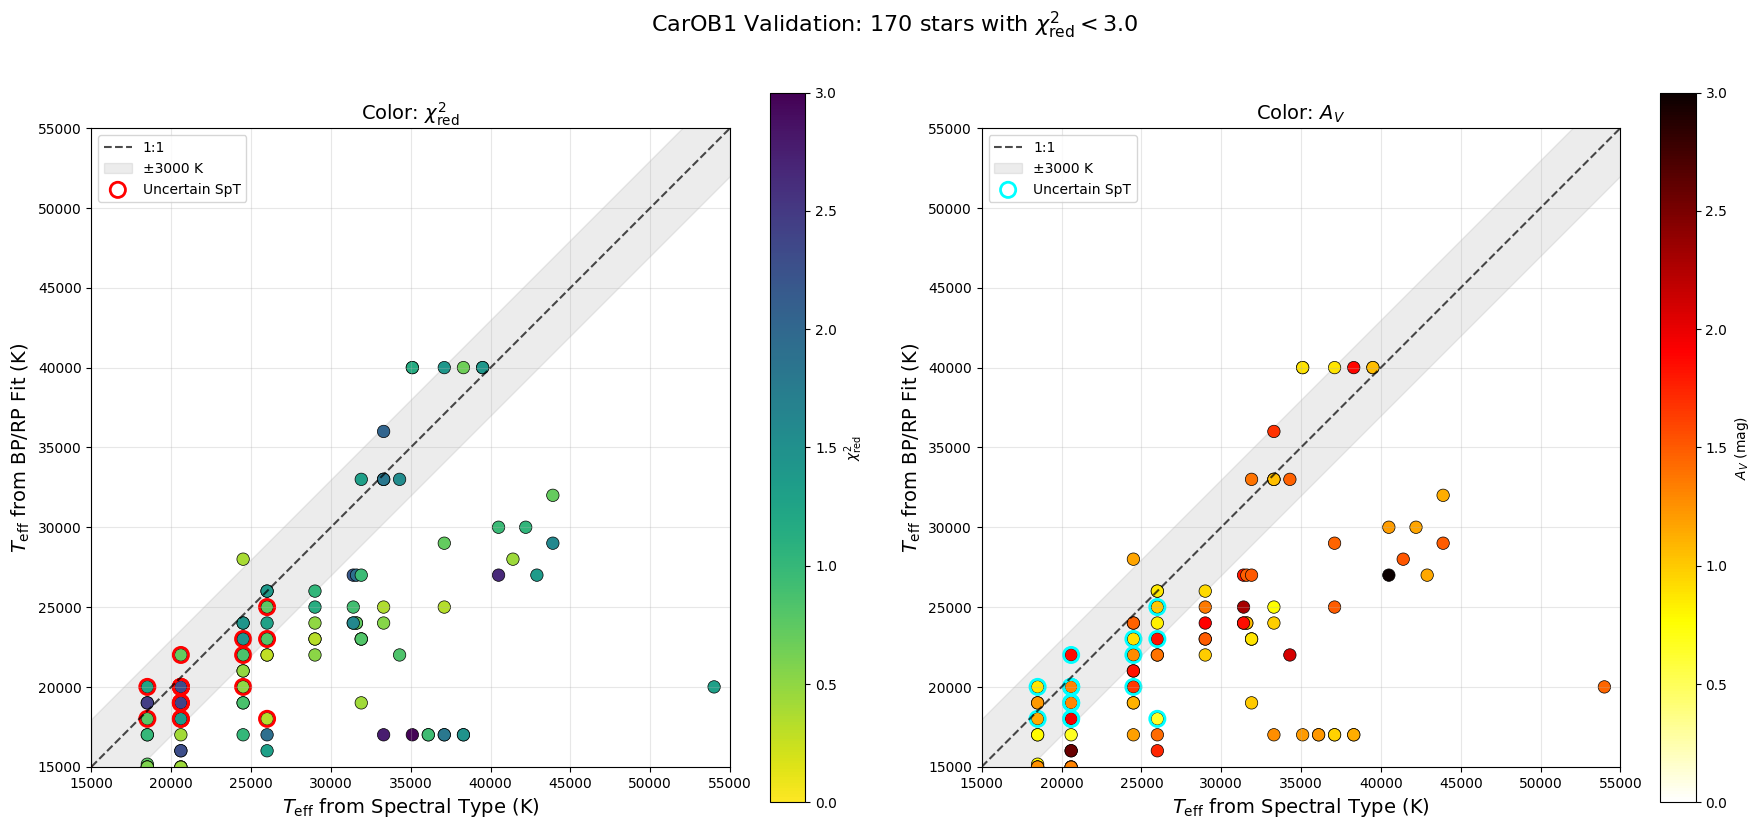


Plot saved to CarOB1_Teff_validation.png


In [56]:
# Plot 1: Color by chi2
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left panel: Color by chi2
ax = axes[0]
teff_range = np.array([15000, 55000])
ax.plot(teff_range, teff_range, 'k--', lw=1.5, alpha=0.7, label='1:1')
ax.fill_between(teff_range, teff_range - 3000, teff_range + 3000, 
                alpha=0.15, color='gray', label='±3000 K')

scatter = ax.scatter(df_valid['Teff_SpT'], df_valid['Teff_fit'],
                     c=df_valid['chi2_red_fit'], cmap='viridis_r',
                     s=80, edgecolor='k', linewidth=0.5,
                     vmin=0, vmax=CHI2_THRESHOLD)
cbar = plt.colorbar(scatter, ax=ax, label=r'$\chi^2_{\rm red}$')

uncertain = df_valid[df_valid['SpT_uncertain']]
if len(uncertain) > 0:
    ax.scatter(uncertain['Teff_SpT'], uncertain['Teff_fit'],
               s=120, facecolors='none', edgecolors='red', linewidth=2,
               label='Uncertain SpT')

ax.set_xlabel(r'$T_{\rm eff}$ from Spectral Type (K)', fontsize=14)
ax.set_ylabel(r'$T_{\rm eff}$ from BP/RP Fit (K)', fontsize=14)
ax.set_title(f'Color: $\\chi^2_{{\\rm red}}$', fontsize=14)
ax.set_xlim(15000, 55000)
ax.set_ylim(15000, 55000)
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# Right panel: Color by A_V
ax = axes[1]
ax.plot(teff_range, teff_range, 'k--', lw=1.5, alpha=0.7, label='1:1')
ax.fill_between(teff_range, teff_range - 3000, teff_range + 3000, 
                alpha=0.15, color='gray', label='±3000 K')

scatter2 = ax.scatter(df_valid['Teff_SpT'], df_valid['Teff_fit'],
                      c=df_valid['A_V_fit'], cmap='hot_r',
                      s=80, edgecolor='k', linewidth=0.5,
                      vmin=0, vmax=3.0)
cbar2 = plt.colorbar(scatter2, ax=ax, label=r'$A_V$ (mag)')

if len(uncertain) > 0:
    ax.scatter(uncertain['Teff_SpT'], uncertain['Teff_fit'],
               s=120, facecolors='none', edgecolors='cyan', linewidth=2,
               label='Uncertain SpT')

ax.set_xlabel(r'$T_{\rm eff}$ from Spectral Type (K)', fontsize=14)
ax.set_ylabel(r'$T_{\rm eff}$ from BP/RP Fit (K)', fontsize=14)
ax.set_title(f'Color: $A_V$', fontsize=14)
ax.set_xlim(15000, 55000)
ax.set_ylim(15000, 55000)
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle(f'CarOB1 Validation: {len(df_valid)} stars with $\\chi^2_{{\\rm red}} < {CHI2_THRESHOLD}$', 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('CarOB1_Teff_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to CarOB1_Teff_validation.png")

In [57]:
# Compute statistics
delta_teff = df_valid['Teff_fit'] - df_valid['Teff_SpT']

print("=" * 50)
print("Temperature Comparison Statistics")
print("=" * 50)
print(f"N stars:           {len(df_valid)}")
print(f"Mean offset:       {delta_teff.mean():+.0f} K")
print(f"Median offset:     {delta_teff.median():+.0f} K")
print(f"Std deviation:     {delta_teff.std():.0f} K")
print(f"RMS:               {np.sqrt((delta_teff**2).mean()):.0f} K")
print(f"MAD:               {np.abs(delta_teff).median():.0f} K")
print(f"\nRange of offsets:  {delta_teff.min():+.0f} to {delta_teff.max():+.0f} K")
print(f"Outliers (|Δ|>5000K): {(np.abs(delta_teff) > 5000).sum()}")

Temperature Comparison Statistics
N stars:           170
Mean offset:       -4371 K
Median offset:     -2600 K
Std deviation:     5759 K
RMS:               7216 K
MAD:               2600 K

Range of offsets:  -34000 to +9300 K
Outliers (|Δ|>5000K): 49


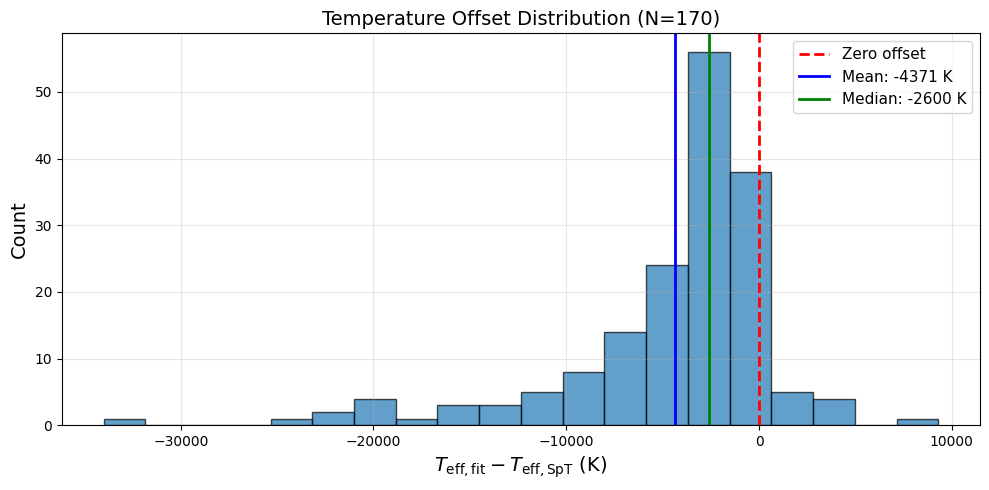

In [58]:
# Histogram of offsets
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(delta_teff, bins=20, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', lw=2, label='Zero offset')
ax.axvline(delta_teff.mean(), color='blue', linestyle='-', lw=2, 
           label=f'Mean: {delta_teff.mean():+.0f} K')
ax.axvline(delta_teff.median(), color='green', linestyle='-', lw=2,
           label=f'Median: {delta_teff.median():+.0f} K')

ax.set_xlabel(r'$T_{\rm eff,fit} - T_{\rm eff,SpT}$ (K)', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.set_title(f'Temperature Offset Distribution (N={len(df_valid)})', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('CarOB1_Teff_offset_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Detailed View by Spectral Type

In [59]:
# Group by spectral type
spt_stats = df_valid.groupby('SpT_parsed').agg({
    'Teff_SpT': 'first',
    'Teff_fit': ['mean', 'std', 'count'],
    'chi2_red_fit': 'mean'
}).round(0)

spt_stats.columns = ['Teff_calib', 'Teff_fit_mean', 'Teff_fit_std', 'N', 'chi2_mean']
spt_stats['Delta'] = spt_stats['Teff_fit_mean'] - spt_stats['Teff_calib']
spt_stats = spt_stats.sort_values('Teff_calib', ascending=False)

print("Statistics by Spectral Type:")
spt_stats

Statistics by Spectral Type:


,Teff_calib,Teff_fit_mean,Teff_fit_std,N,chi2_mean,Delta
SpT_parsed,,,,,,
O2,54000.0,20000.0,NaN,1,1.0,-34000.0
O3.5,43900.0,30500.0,2121.0,2,1.0,-13400.0
O4,42900.0,27000.0,NaN,1,1.0,-15900.0
O4.5,42200.0,30000.0,NaN,1,1.0,-12200.0
O5,41400.0,28000.0,NaN,1,0.0,-13400.0
O5.5,40500.0,28500.0,2121.0,2,2.0,-12000.0
O6,39500.0,40000.0,0.0,2,1.0,500.0
O6.5,38300.0,24667.0,13279.0,3,1.0,-13633.0
O7,37100.0,25600.0,9581.0,5,1.0,-11500.0


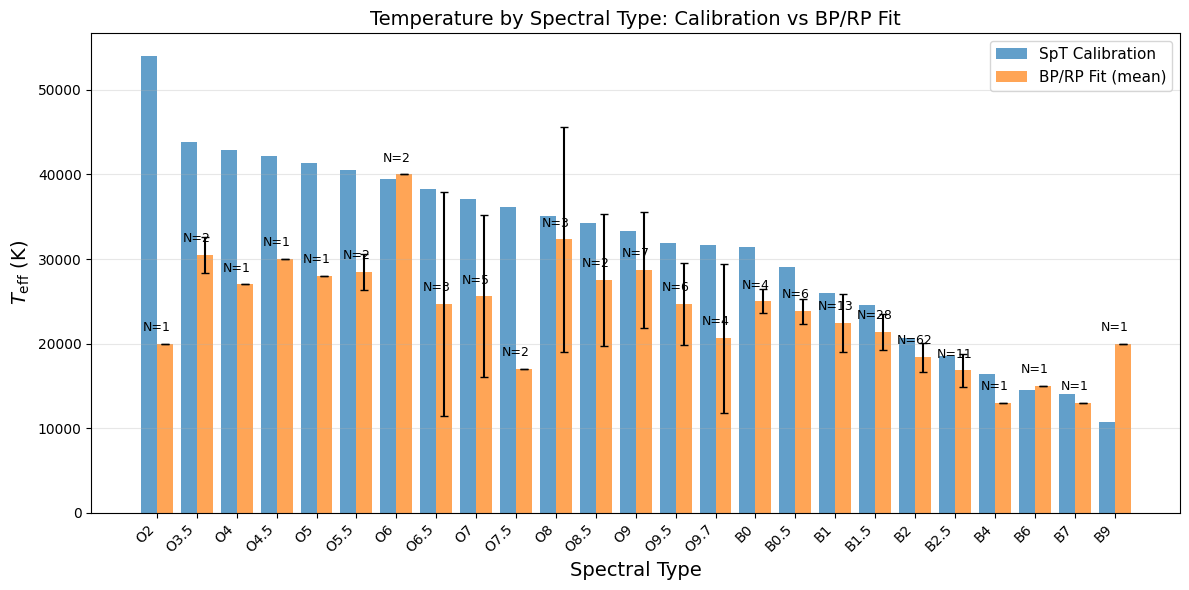

In [60]:
# Plot by spectral type
fig, ax = plt.subplots(figsize=(12, 6))

# Sort spectral types by temperature
spt_order = spt_stats.index.tolist()

# Plot calibration temperatures
x = np.arange(len(spt_order))
ax.bar(x - 0.2, spt_stats['Teff_calib'], width=0.4, label='SpT Calibration', alpha=0.7)
ax.bar(x + 0.2, spt_stats['Teff_fit_mean'], width=0.4, label='BP/RP Fit (mean)', alpha=0.7,
       yerr=spt_stats['Teff_fit_std'].fillna(0), capsize=3)

ax.set_xticks(x)
ax.set_xticklabels(spt_order, rotation=45, ha='right')
ax.set_xlabel('Spectral Type', fontsize=14)
ax.set_ylabel(r'$T_{\rm eff}$ (K)', fontsize=14)
ax.set_title('Temperature by Spectral Type: Calibration vs BP/RP Fit', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add count labels
for i, (spt, row) in enumerate(spt_stats.iterrows()):
    ax.annotate(f'N={int(row["N"])}', (i, row['Teff_fit_mean'] + 1500), 
                ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('CarOB1_Teff_by_SpT.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Outlier Analysis

In [61]:
# Identify outliers (|Δ| > 5000 K)
OUTLIER_THRESHOLD = 5000  # K

df_valid['Delta_Teff'] = df_valid['Teff_fit'] - df_valid['Teff_SpT']
outliers = df_valid[np.abs(df_valid['Delta_Teff']) > OUTLIER_THRESHOLD]

print(f"Outliers with |ΔTeff| > {OUTLIER_THRESHOLD} K: {len(outliers)}")
if len(outliers) > 0:
    print()
    display_cols = ['Name_clean', 'SpT_parsed', 'Teff_SpT', 'Teff_fit', 'Delta_Teff', 
                    'chi2_red_fit', 'logg_fit', 'A_V_fit', 'model_source']
    print(outliers[display_cols].to_string(index=False))

Outliers with |ΔTeff| > 5000 K: 49

             Name_clean SpT_parsed  Teff_SpT     Teff_fit    Delta_Teff  chi2_red_fit  logg_fit  A_V_fit model_source
           QZ Car Aa,Ac       O9.7   31600.0  7599.999106 -24000.000894      1.792219  2.325204 0.420962      PHOENIX
           HD 93 129 Aa         O2   54000.0 19999.995057 -34000.004943      1.302839  2.389984 1.446472         PoWR
              HD 93 403         O5   41400.0 28000.000201 -13399.999799      0.436064  2.700168 1.519404         PoWR
          HD 93 250 A,B         O4   42900.0 27000.000476 -15899.999524      1.369774  2.700013 1.158141         PoWR
              HD 93 205       O3.5   43900.0 31999.999928 -11900.000072      0.711599  3.177450 1.136087         PoWR
          HD 93 160 A,B         O7   37100.0 17000.133120 -20099.866880      1.287755  2.288866 1.134768         PoWR
              HD 93 130       O6.5   38300.0 17000.109209 -21299.890791      1.705896  2.290696 1.328159         PoWR
          HD 93 222 

In [62]:
# Check if outliers have unusual parameters
print("\n" + "="*50)
print("Comparison: Outliers vs Good matches")
print("="*50)

good_matches = df_valid[np.abs(df_valid['Delta_Teff']) <= OUTLIER_THRESHOLD]

print(f"\nN outliers: {len(outliers)}, N good: {len(good_matches)}")

for col in ['chi2_red_fit', 'logg_fit', 'A_V_fit', 'R_V_fit']:
    if len(outliers) > 0:
        print(f"\n{col}:")
        print(f"  Outliers: {outliers[col].mean():.2f} ± {outliers[col].std():.2f}")
        print(f"  Good:     {good_matches[col].mean():.2f} ± {good_matches[col].std():.2f}")


Comparison: Outliers vs Good matches

N outliers: 49, N good: 121

chi2_red_fit:
  Outliers: 1.05 ± 0.66
  Good:     0.90 ± 0.54

logg_fit:
  Outliers: 3.11 ± 0.76
  Good:     4.06 ± 0.38

A_V_fit:
  Outliers: 1.24 ± 0.49
  Good:     1.19 ± 0.37

R_V_fit:
  Outliers: 3.48 ± 0.86
  Good:     2.89 ± 0.52


## 6b. A_V as Source of Systematics

Extinction (A_V) may introduce systematics in Teff determination. Here we analyze whether high A_V correlates with larger temperature offsets, and compare A_V distributions between good matches and outliers across spectral type bins.

In [63]:
# A_V statistics by spectral type bin for good vs outlier matches
print("="*70)
print("A_V Analysis by Spectral Type: Good Matches vs Outliers")
print("="*70)

# Define temperature bins for spectral types
df_valid['SpT_bin'] = pd.cut(df_valid['Teff_SpT'], 
                              bins=[10000, 20000, 30000, 40000, 55000],
                              labels=['B (10-20kK)', 'late O (20-30kK)', 'mid O (30-40kK)', 'early O (40-55kK)'])

# Separate good and outlier samples
good_matches = df_valid[np.abs(df_valid['Delta_Teff']) <= OUTLIER_THRESHOLD]
outlier_matches = df_valid[np.abs(df_valid['Delta_Teff']) > OUTLIER_THRESHOLD]

# Compute stats by bin
print(f"\n{'SpT Bin':<20} {'N_good':>8} {'A_V_good':>10} {'N_out':>8} {'A_V_out':>10} {'Δ(A_V)':>10}")
print("-"*70)

for bin_label in ['early O (40-55kK)', 'mid O (30-40kK)', 'late O (20-30kK)', 'B (10-20kK)']:
    g = good_matches[good_matches['SpT_bin'] == bin_label]
    o = outlier_matches[outlier_matches['SpT_bin'] == bin_label]
    
    av_good = g['A_V_fit'].mean() if len(g) > 0 else np.nan
    av_out = o['A_V_fit'].mean() if len(o) > 0 else np.nan
    delta_av = av_out - av_good if (not np.isnan(av_good) and not np.isnan(av_out)) else np.nan
    
    print(f"{bin_label:<20} {len(g):>8} {av_good:>10.2f} {len(o):>8} {av_out:>10.2f} {delta_av:>+10.2f}" if not np.isnan(delta_av) 
          else f"{bin_label:<20} {len(g):>8} {av_good:>10.2f} {len(o):>8} {'---':>10} {'---':>10}")

print("-"*70)
print(f"{'TOTAL':<20} {len(good_matches):>8} {good_matches['A_V_fit'].mean():>10.2f} "
      f"{len(outlier_matches):>8} {outlier_matches['A_V_fit'].mean():>10.2f} "
      f"{outlier_matches['A_V_fit'].mean() - good_matches['A_V_fit'].mean():>+10.2f}")

A_V Analysis by Spectral Type: Good Matches vs Outliers

SpT Bin                N_good   A_V_good    N_out    A_V_out     Δ(A_V)
----------------------------------------------------------------------
early O (40-55kK)           0        nan        8        ---        ---
mid O (30-40kK)            15       1.34       23       1.22      -0.12
late O (20-30kK)           92       1.19       17       1.18      -0.01
B (10-20kK)                14       1.06        1       0.67      -0.39
----------------------------------------------------------------------
TOTAL                     121       1.19       49       1.24      +0.05


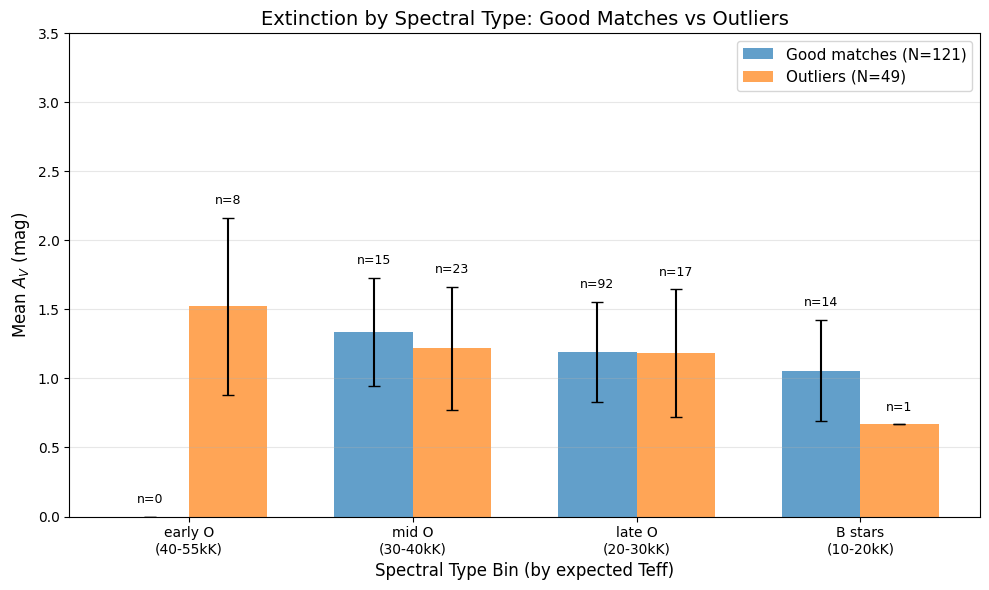

In [64]:
# Visualize A_V by SpT bin
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data
bin_labels = ['early O\n(40-55kK)', 'mid O\n(30-40kK)', 'late O\n(20-30kK)', 'B stars\n(10-20kK)']
bin_codes = ['early O (40-55kK)', 'mid O (30-40kK)', 'late O (20-30kK)', 'B (10-20kK)']

x = np.arange(len(bin_labels))
width = 0.35

# Compute means and stds
good_avs = [good_matches[good_matches['SpT_bin'] == b]['A_V_fit'].mean() for b in bin_codes]
good_stds = [good_matches[good_matches['SpT_bin'] == b]['A_V_fit'].std() for b in bin_codes]
out_avs = [outlier_matches[outlier_matches['SpT_bin'] == b]['A_V_fit'].mean() for b in bin_codes]
out_stds = [outlier_matches[outlier_matches['SpT_bin'] == b]['A_V_fit'].std() for b in bin_codes]

# Replace NaN with 0 for plotting
good_avs = [v if not np.isnan(v) else 0 for v in good_avs]
out_avs = [v if not np.isnan(v) else 0 for v in out_avs]
good_stds = [v if not np.isnan(v) else 0 for v in good_stds]
out_stds = [v if not np.isnan(v) else 0 for v in out_stds]

bars1 = ax.bar(x - width/2, good_avs, width, yerr=good_stds, capsize=4,
               label=f'Good matches (N={len(good_matches)})', alpha=0.7)
bars2 = ax.bar(x + width/2, out_avs, width, yerr=out_stds, capsize=4,
               label=f'Outliers (N={len(outlier_matches)})', alpha=0.7)

# Add count labels
for i, (g, o) in enumerate(zip(
    [len(good_matches[good_matches['SpT_bin'] == b]) for b in bin_codes],
    [len(outlier_matches[outlier_matches['SpT_bin'] == b]) for b in bin_codes])):
    ax.annotate(f'n={g}', (i - width/2, good_avs[i] + good_stds[i] + 0.1), ha='center', fontsize=9)
    if o > 0:
        ax.annotate(f'n={o}', (i + width/2, out_avs[i] + out_stds[i] + 0.1), ha='center', fontsize=9)

ax.set_ylabel(r'Mean $A_V$ (mag)', fontsize=12)
ax.set_xlabel('Spectral Type Bin (by expected Teff)', fontsize=12)
ax.set_title(r'Extinction by Spectral Type: Good Matches vs Outliers', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(bin_labels)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 3.5)

plt.tight_layout()
plt.savefig('CarOB1_AV_by_SpT_bin.png', dpi=150, bbox_inches='tight')
plt.show()

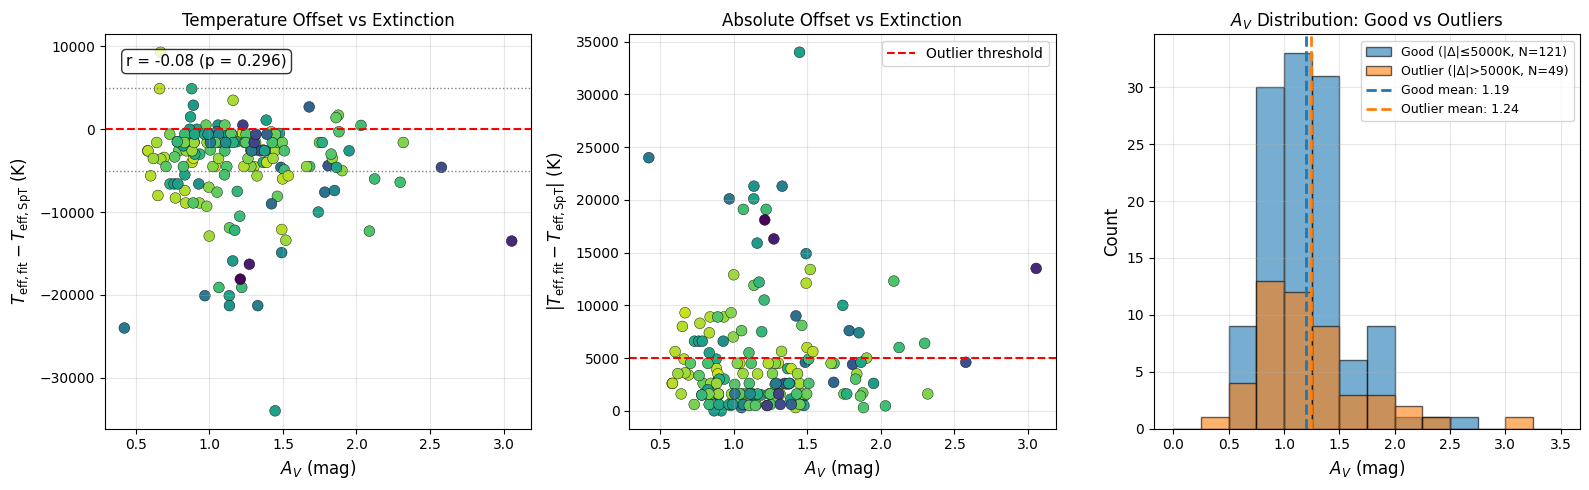


Plot saved to CarOB1_AV_systematics.png


In [65]:
# Correlation between A_V and temperature offset
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: Delta_Teff vs A_V
ax = axes[0]
ax.scatter(df_valid['A_V_fit'], df_valid['Delta_Teff'], 
           c=df_valid['chi2_red_fit'], cmap='viridis_r', 
           s=60, edgecolor='k', linewidth=0.3, vmin=0, vmax=CHI2_THRESHOLD)
ax.axhline(0, color='red', linestyle='--', lw=1.5)
ax.axhline(-5000, color='gray', linestyle=':', lw=1)
ax.axhline(5000, color='gray', linestyle=':', lw=1)
ax.set_xlabel(r'$A_V$ (mag)', fontsize=12)
ax.set_ylabel(r'$T_{\rm eff,fit} - T_{\rm eff,SpT}$ (K)', fontsize=12)
ax.set_title('Temperature Offset vs Extinction', fontsize=12)
ax.grid(True, alpha=0.3)

# Add correlation
from scipy import stats
r, p = stats.pearsonr(df_valid['A_V_fit'], df_valid['Delta_Teff'])
ax.text(0.05, 0.95, f'r = {r:.2f} (p = {p:.3f})', transform=ax.transAxes, 
        fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Middle: |Delta_Teff| vs A_V
ax = axes[1]
ax.scatter(df_valid['A_V_fit'], np.abs(df_valid['Delta_Teff']), 
           c=df_valid['chi2_red_fit'], cmap='viridis_r',
           s=60, edgecolor='k', linewidth=0.3, vmin=0, vmax=CHI2_THRESHOLD)
ax.axhline(5000, color='red', linestyle='--', lw=1.5, label='Outlier threshold')
ax.set_xlabel(r'$A_V$ (mag)', fontsize=12)
ax.set_ylabel(r'$|T_{\rm eff,fit} - T_{\rm eff,SpT}|$ (K)', fontsize=12)
ax.set_title('Absolute Offset vs Extinction', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Right: Histogram of A_V for good vs outlier
ax = axes[2]
good = df_valid[np.abs(df_valid['Delta_Teff']) <= OUTLIER_THRESHOLD]
bad = df_valid[np.abs(df_valid['Delta_Teff']) > OUTLIER_THRESHOLD]

bins = np.linspace(0, 3.5, 15)
ax.hist(good['A_V_fit'], bins=bins, alpha=0.6, label=f'Good (|Δ|≤5000K, N={len(good)})', edgecolor='black')
ax.hist(bad['A_V_fit'], bins=bins, alpha=0.6, label=f'Outlier (|Δ|>5000K, N={len(bad)})', edgecolor='black')
ax.axvline(good['A_V_fit'].mean(), color='C0', linestyle='--', lw=2, label=f'Good mean: {good["A_V_fit"].mean():.2f}')
ax.axvline(bad['A_V_fit'].mean(), color='C1', linestyle='--', lw=2, label=f'Outlier mean: {bad["A_V_fit"].mean():.2f}')
ax.set_xlabel(r'$A_V$ (mag)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(r'$A_V$ Distribution: Good vs Outliers', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('CarOB1_AV_systematics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to CarOB1_AV_systematics.png")

## 6c. Luminosity Class vs M_G Comparison

Compare fitted absolute G magnitude (M_G_fit) with expectations from spectral type + luminosity class.

**Calibration sources:**
- Mamajek (2019) for dwarf (LC V) Mv values
- Standard LC offsets from Hipparcos-based calibrations (Wegner 2006, 2007)

In [66]:
# M_G calibration by SpT for dwarfs (LC V) - from Mamajek (2019)
# Note: For hot stars, M_G ≈ Mv (small bolometric correction difference in G-band)
MG_DWARF_CALIBRATION = {
    # O stars (Mv from Mamajek, M_G very similar for hot stars)
    'O2': -6.0,   # Extrapolated
    'O2.5': -5.9,
    'O3': -5.8,
    'O3.5': -5.65,
    'O4': -5.5,
    'O4.5': -5.4,
    'O5': -5.35,
    'O5.5': -5.2,
    'O6': -5.1,
    'O6.5': -4.95,
    'O7': -4.8,
    'O7.5': -4.65,
    'O8': -4.5,
    'O8.5': -4.35,
    'O9': -4.2,
    'O9.5': -4.05,
    'O9.7': -3.95,
    # B stars
    'B0': -3.9,
    'B0.5': -3.5,
    'B1': -3.0,
    'B1.5': -2.6,
    'B2': -1.8,
    'B2.5': -1.5,
    'B3': -1.2,
    'B4': -1.0,
    'B5': -0.85,
    'B6': -0.55,
    'B7': -0.4,
    'B8': 0.0,
    'B9': 0.5,
}

# Luminosity class offsets (brighter = more negative M_G)
# Based on Hipparcos studies (Wegner 2006, 2007)
# For O stars, differences are small; for B stars, larger
LC_OFFSETS = {
    'V': 0.0,      # Dwarfs (reference)
    'V:': 0.0,     # Uncertain dwarf
    'IV': -0.3,    # Subgiants
    'IV:': -0.3,
    'III': -0.8,   # Giants
    'III:': -0.8,
    'II-III': -1.2,
    'II': -1.5,    # Bright giants
    'II:': -1.5,
    'Ib': -2.0,    # Supergiants
    'Iab': -2.5,
    'Ia': -3.0,
    'I': -2.5,     # Generic supergiant
}

def parse_luminosity_class(lc_string):
    """Parse luminosity class string."""
    if not lc_string or not isinstance(lc_string, str):
        return None
    lc = lc_string.strip()
    if lc in ['---', '']:
        return None
    return lc

def get_MG_from_spt_lc(spt, lc):
    """Get expected M_G from spectral type and luminosity class."""
    if spt is None:
        return None
    mg_dwarf = MG_DWARF_CALIBRATION.get(spt, None)
    if mg_dwarf is None:
        return None
    if lc is None:
        lc = 'V'
    offset = LC_OFFSETS.get(lc, 0.0)
    return mg_dwarf + offset

print("M_G calibration test:")
for spt in ['O3', 'O7', 'B1', 'B2']:
    for lc in ['V', 'III', 'I']:
        mg = get_MG_from_spt_lc(spt, lc)
        print(f"  {spt} {lc}: M_G = {mg:.1f}")

M_G calibration test:
  O3 V: M_G = -5.8
  O3 III: M_G = -6.6
  O3 I: M_G = -8.3
  O7 V: M_G = -4.8
  O7 III: M_G = -5.6
  O7 I: M_G = -7.3
  B1 V: M_G = -3.0
  B1 III: M_G = -3.8
  B1 I: M_G = -5.5
  B2 V: M_G = -1.8
  B2 III: M_G = -2.6
  B2 I: M_G = -4.3


In [67]:
# Load luminosity class data and merge with validation sample
with fits.open('CarOB1_OBcluster_Sptypes.fits') as hdul:
    spt_data = hdul[1].data
    df_lc = pd.DataFrame({
        'Name': [s.strip() for s in spt_data['Name']],
        'LC_GES': [s.strip() for s in spt_data['LC-GES']],
        'LC_GOSSS': [s.strip() for s in spt_data['LC-GOSSS']],
    })

# Merge LC data with validation sample
df_lc_merged = pd.merge(df_valid, df_lc, left_on='Name_clean', right_on='Name', 
                        how='left', suffixes=('', '_lc'))

# Get best LC (prefer GOSSS, fall back to GES)
def get_best_lc(row):
    lc = parse_luminosity_class(row['LC_GOSSS'])
    if lc is not None:
        return lc, 'GOSSS'
    lc = parse_luminosity_class(row['LC_GES'])
    if lc is not None:
        return lc, 'GES'
    return None, None

lc_parsed = df_lc_merged.apply(get_best_lc, axis=1)
df_lc_merged['LC_parsed'] = [p[0] for p in lc_parsed]
df_lc_merged['LC_source'] = [p[1] for p in lc_parsed]

# Compute expected M_G from SpT + LC
df_lc_merged['M_G_LC'] = df_lc_merged.apply(
    lambda row: get_MG_from_spt_lc(row['SpT_parsed'], row['LC_parsed']), axis=1)

# Filter to stars with valid M_G_LC
mask_has_lc = df_lc_merged['M_G_LC'].notna()
df_lc_valid = df_lc_merged[mask_has_lc].copy()

print(f"Stars with valid LC + SpT for M_G comparison: {len(df_lc_valid)}")
print(f"\nLuminosity class distribution:")
print(df_lc_valid['LC_parsed'].value_counts())

# Show sample
print(f"\nSample of M_G comparison:")
display_cols = ['Name_clean', 'SpT_parsed', 'LC_parsed', 'M_G_LC', 'M_G_fit', 'chi2_red_fit']
df_lc_valid[display_cols].head(15)

Stars with valid LC + SpT for M_G comparison: 170

Luminosity class distribution:
LC_parsed
V         145
IV         11
III         7
I           2
Ib          1
II-III      1
V:          1
Ia          1
II:         1
Name: count, dtype: int64

Sample of M_G comparison:


,Name_clean,SpT_parsed,LC_parsed,M_G_LC,M_G_fit,chi2_red_fit
0,"QZ Car Aa,Ac",O9.7,Ib,-5.95,-3.672272,1.792219
1,HD 93 129 Aa,O2,I,-8.50,-8.079831,1.302839
2,HD 93 403,O5,I,-7.85,-8.095148,0.436064
3,"HD 93 250 A,B",O4,IV,-5.80,-7.834982,1.369774
4,HD 93 205,O3.5,V,-5.65,-6.933405,0.711599
5,"HD 93 160 A,B",O7,III,-5.60,-7.397445,1.287755
6,HD 93 130,O6.5,III,-5.75,-7.375899,1.705896
7,"HD 93 222 A,B",O7,V,-4.80,-7.420002,1.794937
8,"HDE 303 308 A,B",O4.5,V,-5.40,-7.454073,1.031446
9,HD 93 249 A,O9,III,-5.00,-5.121073,0.402082


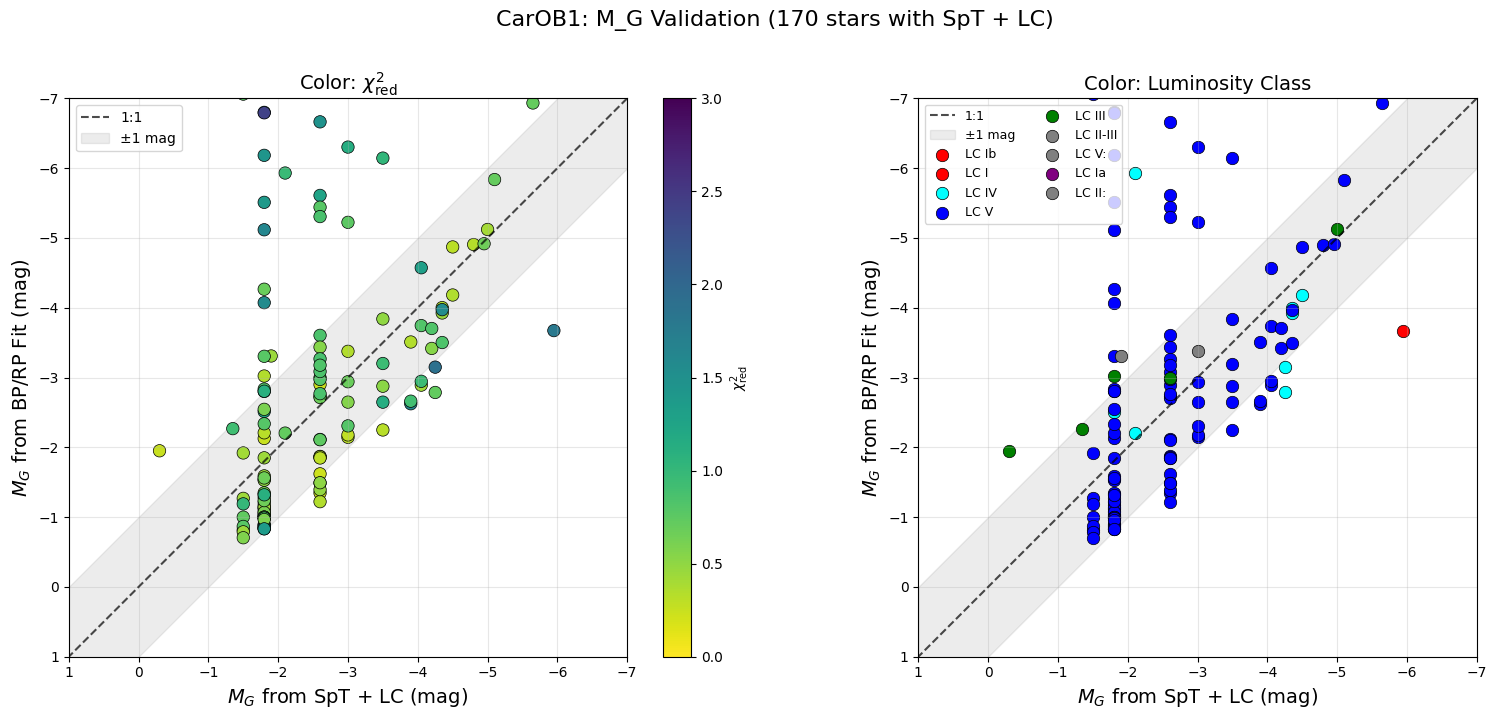


Plot saved to CarOB1_MG_validation.png


In [68]:
# M_G comparison plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: M_G comparison colored by chi2
ax = axes[0]
mg_range = np.array([-7, 1])
ax.plot(mg_range, mg_range, 'k--', lw=1.5, alpha=0.7, label='1:1')
ax.fill_between(mg_range, mg_range - 1, mg_range + 1, 
                alpha=0.15, color='gray', label='±1 mag')

scatter = ax.scatter(df_lc_valid['M_G_LC'], df_lc_valid['M_G_fit'],
                     c=df_lc_valid['chi2_red_fit'], cmap='viridis_r',
                     s=80, edgecolor='k', linewidth=0.5,
                     vmin=0, vmax=CHI2_THRESHOLD)
cbar = plt.colorbar(scatter, ax=ax, label=r'$\chi^2_{\rm red}$')

ax.set_xlabel(r'$M_G$ from SpT + LC (mag)', fontsize=14)
ax.set_ylabel(r'$M_G$ from BP/RP Fit (mag)', fontsize=14)
ax.set_title(f'Color: $\\chi^2_{{\\rm red}}$', fontsize=14)
ax.set_xlim(-7, 1)
ax.set_ylim(-7, 1)
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.invert_xaxis()
ax.invert_yaxis()

# Right: M_G comparison colored by LC
ax = axes[1]
ax.plot(mg_range, mg_range, 'k--', lw=1.5, alpha=0.7, label='1:1')
ax.fill_between(mg_range, mg_range - 1, mg_range + 1, 
                alpha=0.15, color='gray', label='±1 mag')

# Color by luminosity class
lc_colors = {'V': 'blue', 'IV': 'cyan', 'III': 'green', 'II': 'orange', 
             'Ib': 'red', 'Iab': 'darkred', 'Ia': 'purple', 'I': 'red'}
for lc in df_lc_valid['LC_parsed'].unique():
    mask = df_lc_valid['LC_parsed'] == lc
    color = lc_colors.get(lc, 'gray')
    ax.scatter(df_lc_valid.loc[mask, 'M_G_LC'], df_lc_valid.loc[mask, 'M_G_fit'],
               c=color, s=80, edgecolor='k', linewidth=0.5, label=f'LC {lc}')

ax.set_xlabel(r'$M_G$ from SpT + LC (mag)', fontsize=14)
ax.set_ylabel(r'$M_G$ from BP/RP Fit (mag)', fontsize=14)
ax.set_title('Color: Luminosity Class', fontsize=14)
ax.set_xlim(-7, 1)
ax.set_ylim(-7, 1)
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
ax.invert_xaxis()
ax.invert_yaxis()

plt.suptitle(f'CarOB1: M_G Validation ({len(df_lc_valid)} stars with SpT + LC)', 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('CarOB1_MG_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to CarOB1_MG_validation.png")

In [69]:
# M_G statistics
delta_MG = df_lc_valid['M_G_fit'] - df_lc_valid['M_G_LC']

print("="*60)
print("M_G Comparison Statistics")
print("="*60)
print(f"N stars with SpT + LC:   {len(df_lc_valid)}")
print(f"Mean offset:             {delta_MG.mean():+.2f} mag")
print(f"Median offset:           {delta_MG.median():+.2f} mag")
print(f"Std deviation:           {delta_MG.std():.2f} mag")
print(f"RMS:                     {np.sqrt((delta_MG**2).mean()):.2f} mag")
print(f"MAD:                     {np.abs(delta_MG).median():.2f} mag")
print(f"\nRange of offsets:        {delta_MG.min():+.2f} to {delta_MG.max():+.2f} mag")
print(f"Outliers (|Δ|>2 mag):    {(np.abs(delta_MG) > 2).sum()}")

# Statistics by LC
print("\n" + "="*60)
print("M_G Statistics by Luminosity Class")
print("="*60)
print(f"\n{'LC':<10} {'N':>5} {'Mean ΔM_G':>12} {'Std':>8} {'Median':>10}")
print("-"*50)
for lc in df_lc_valid['LC_parsed'].value_counts().index:
    subset = df_lc_valid[df_lc_valid['LC_parsed'] == lc]
    delta = subset['M_G_fit'] - subset['M_G_LC']
    print(f"{lc:<10} {len(subset):>5} {delta.mean():>+12.2f} {delta.std():>8.2f} {delta.median():>+10.2f}")

M_G Comparison Statistics
N stars with SpT + LC:   170
Mean offset:             -1.17 mag
Median offset:           -0.15 mag
Std deviation:           2.52 mag
RMS:                     2.77 mag
MAD:                     0.91 mag

Range of offsets:        -9.66 to +2.28 mag
Outliers (|Δ|>2 mag):    53

M_G Statistics by Luminosity Class

LC             N    Mean ΔM_G      Std     Median
--------------------------------------------------
V            145        -1.24     2.66      -0.05
IV            11        -0.79     1.83      -0.10
III            7        -1.10     0.65      -1.22
I              2        +0.09     0.47      +0.09
Ib             1        +2.28      nan      +2.28
II-III         1        -2.01      nan      -2.01
V:             1        -0.38      nan      -0.38
Ia             1        -0.88      nan      -0.88
II:            1        -1.41      nan      -1.41


## 7. Summary

In [70]:
print("="*60)
print("CarOB1 Validation Summary")
print("="*60)
print(f"\nInput:")
print(f"  Stars with BP/RP fits:        {len(df_fits)}")
print(f"  Stars with spectral types:    {len(df_spt)}")
print(f"  Matched stars:                {len(df_merged)}")

print(f"\nQuality cuts:")
print(f"  chi2_red < {CHI2_THRESHOLD}:             {mask_good_fit.sum()}")
print(f"  Valid OB spectral type:       {mask_has_spt.sum()}")
print(f"  Final validation sample:      {len(df_valid)}")

print(f"\nTemperature comparison:")
print(f"  Mean offset (fit - SpT):      {delta_teff.mean():+.0f} K")
print(f"  Median offset:                {delta_teff.median():+.0f} K")
print(f"  RMS scatter:                  {np.sqrt((delta_teff**2).mean()):.0f} K")
print(f"  Outliers (|Δ| > 5000 K):      {(np.abs(delta_teff) > 5000).sum()}")

print(f"\nA_V systematics:")
print(f"  Mean A_V (good matches):      {good_matches['A_V_fit'].mean():.2f} mag")
print(f"  Mean A_V (outliers):          {outlier_matches['A_V_fit'].mean():.2f} mag")

print(f"\nM_G comparison (SpT + LC):")
print(f"  Stars with valid LC:          {len(df_lc_valid)}")
if len(df_lc_valid) > 0:
    delta_MG = df_lc_valid['M_G_fit'] - df_lc_valid['M_G_LC']
    print(f"  Mean M_G offset:              {delta_MG.mean():+.2f} mag")
    print(f"  RMS scatter:                  {np.sqrt((delta_MG**2).mean()):.2f} mag")

print(f"\nSpectral type sources:")
print(f"  GOSSS: {(df_valid['SpT_source'] == 'GOSSS').sum()}")
print(f"  GES:   {(df_valid['SpT_source'] == 'GES').sum()}")

print(f"\nOutput files:")
print(f"  CarOB1_Teff_validation.png      - Teff comparison (color: chi2, A_V)")
print(f"  CarOB1_Teff_offset_histogram.png")
print(f"  CarOB1_Teff_by_SpT.png")
print(f"  CarOB1_AV_systematics.png       - A_V vs Teff offset analysis")
print(f"  CarOB1_AV_by_SpT_bin.png        - A_V by spectral type bin")
print(f"  CarOB1_MG_validation.png        - M_G comparison (SpT+LC vs fit)")
print(f"  CarOB1_Teff_validation.csv      - Validation results table")

CarOB1 Validation Summary

Input:
  Stars with BP/RP fits:        265
  Stars with spectral types:    316
  Matched stars:                265

Quality cuts:
  chi2_red < 3.0:             207
  Valid OB spectral type:       215
  Final validation sample:      170

Temperature comparison:
  Mean offset (fit - SpT):      -4371 K
  Median offset:                -2600 K
  RMS scatter:                  7216 K
  Outliers (|Δ| > 5000 K):      49

A_V systematics:
  Mean A_V (good matches):      1.19 mag
  Mean A_V (outliers):          1.24 mag

M_G comparison (SpT + LC):
  Stars with valid LC:          170
  Mean M_G offset:              -1.17 mag
  RMS scatter:                  2.77 mag

Spectral type sources:
  GOSSS: 53
  GES:   117

Output files:
  CarOB1_Teff_validation.png      - Teff comparison (color: chi2, A_V)
  CarOB1_Teff_offset_histogram.png
  CarOB1_Teff_by_SpT.png
  CarOB1_AV_systematics.png       - A_V vs Teff offset analysis
  CarOB1_AV_by_SpT_bin.png        - A_V by spectral 

In [71]:
# Save validation results
output_cols = ['source_id', 'Name_clean', 'SpT_parsed', 'SpT_source', 'SpT_uncertain',
               'Teff_SpT', 'Teff_fit', 'Delta_Teff', 'logg_fit', 'A_V_fit', 'R_V_fit',
               'chi2_red_fit', 'logL_fit', 'Mass_fit', 'logAge_fit', 'model_source']

df_valid[output_cols].to_csv('CarOB1_Teff_validation.csv', index=False)
print(f"Saved validation results to CarOB1_Teff_validation.csv ({len(df_valid)} rows)")

Saved validation results to CarOB1_Teff_validation.csv (170 rows)
